## Applying the function I tested to the full dataset

Importing necessary packages

In [116]:
from shapely import wkt, box, Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon, shortest_line
import geopandas as gpd
from plotnine import *

Reading in housing data

In [85]:
full_map_old = gpd.read_file('data/chi_bldg_footprints.geojson')
full_map = full_map_old.to_crs(epsg=26971)

<hr>

## Dropping NAs

In [86]:
full_map.shape

(820606, 47)

In [87]:
## there are 6 NA values that I will filter out 
full_map[full_map['geometry'].isna()].shape

(6, 47)

In [88]:
full_map = full_map.dropna(subset=['geometry'])

<hr>

## Making sure all `stories` values are actually strings

In [95]:
full_map['stories'] = full_map['stories'].astype('int32')

In [97]:
full_map[full_map['stories'].isna()].shape

(0, 47)

<hr>

Reading in updated CTA data

In [92]:
cta_lines_old = gpd.read_file('data/cta_lines_updated.geojson')
cta_lines_projected = cta_lines_old.to_crs(epsg=26971)
cta_line = cta_lines_projected['geometry'].union_all()

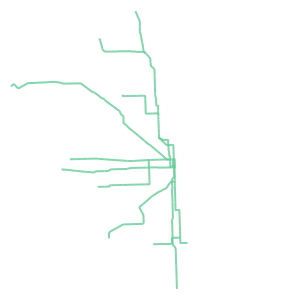

In [98]:
cta_line

Defining my function

In [ ]:
def train_noise(row):
    geom = row['geometry']
    id = row[':id']
    ## 1. find the centroid of the building footprint
    centroid = geom.centroid

    ##### go through each train line geom
    ##### find the distances to each one
    ##### find the shortest distance to a train line
    ##### do all my calculations around that one
    ##### find the next closest line
    ##### do all my calculations around that one
    
    ## 2. find the nearest point btwn CTA lines and centroid
    line = shortest_line(centroid, cta_line)
    ## 4. Measure the distance of that line and store it as a datapoint
    ## I believe EPSG 26971 has a base unit of 1 meter, so this length should already be in meters
    line_len = line.length
    ## 5. Identify all building footprints the line intersects
    intersected_buildings = full_map[full_map['geometry'].intersects(line)]

    ## had to add an if/else statement so my logic didn't break if there were no buildings intersected
    if len(intersected_buildings) > 0:
    ## 6. Record the total # of buildings intersected
    ## I do -1 at the end here because I think the .intersects() argument would count the building the line is connecting as a polygon it intersects with
        num_int_bldgs = len(intersected_buildings)-1
    
    ## 7. Record the total height of buildings intersected (# of stories)
        tot_height = sum(intersected_buildings['stories'])

    ## 8.1 Record the max height of buildings intersected
        max_height = max(intersected_buildings['stories'])
    else:
        num_int_bldgs = 0
        tot_height = 0
        max_height = 0

    return {'geometry': geom, 'centroid': centroid, 'dist_train': line_len, 'shortest_line_1': line,
            'num_intersections': num_int_bldgs, 'tot_stories': tot_height, 'max_height': max_height}

In [ ]:
from tqdm import tqdm
tqdm.pandas(desc="Train noise")

ndf = full_map.progress_apply(train_noise, axis=1, result_type='expand')

Train noise: 100%|██████████| 820600/820600 [10:30:08<00:00, 21.70it/s]  


In [108]:
ndf.set_geometry('geom', inplace=True)

ValueError: Can't do inplace setting when converting from DataFrame to GeoDataFrame

In [114]:
gdf = gpd.GeoDataFrame(ndf, geometry="geom")
gdf = gdf.to_crs(epsg=4326)

ValueError: Cannot transform naive geometries.  Please set a crs on the object first.

In [115]:
gdf.to_file('data/coded_bldgs.geojson', driver='GeoJSON')

/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [104]:
ndf.to_csv('data/coded_bldgs.csv', index=False)

In [107]:
map = ndf.explore()
map.show_in_browser()

AttributeError: 'DataFrame' object has no attribute 'explore'

In [43]:
full_map[full_map[':id']=="row-deiv~cv2p.hsft"]

,:id,:version,:created_at,:updated_at,bldg_id,cdb_city_i,bldg_statu,f_add1,t_add1,pre_dir1,...,year_built,bldg_sq_fo,bldg_condi,condition_,vacancy_st,label_hous,suf_dir1,shape_area,shape_len,geometry
362,row-deiv~cv2p.hsft,rv-4bh6~zwvp.h76w,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,814782,,ACTIVE,600,600,W,...,1912,0.0,,NaT,,600,,14300.5,673.776495132,"MULTIPOLYGON (((357299.663 578838.01, 357326.6..."


In [ ]:
plot = (
    ggplot(ndf) +
    aes(x='dist_train') +
    geom_histogram()
)
plot

,geom,centroid,dist_train,shortest_line_1,num_intersections,tot_stories,max_height,geometry
0,MULTIPOLYGON (((355479.08857873536 559882.9175...,POINT (355474.99948674015 559887.9747490232),3869.322616,LINESTRING (355474.99948674015 559887.97474902...,64,57,2,MULTIPOLYGON (((355479.08857873536 559882.9175...
1,MULTIPOLYGON (((349120.64306184417 590966.3312...,POINT (349126.79651915963 590970.7122816653),2572.864499,LINESTRING (349126.79651915963 590970.71228166...,68,70,3,MULTIPOLYGON (((349120.64306184417 590966.3312...
2,MULTIPOLYGON (((344774.9483704551 584671.43668...,POINT (344784.29312833276 584675.9699260137),4982.003204,LINESTRING (344784.29312833276 584675.96992601...,77,90,3,MULTIPOLYGON (((344774.9483704551 584671.43668...
3,MULTIPOLYGON (((349899.8658202907 570780.75849...,POINT (349902.89966159203 570783.7672950999),971.842090,LINESTRING (349902.89966159203 570783.76729509...,39,35,2,MULTIPOLYGON (((349899.8658202907 570780.75849...
4,MULTIPOLYGON (((355337.81349618576 565171.6652...,POINT (355340.90002362337 565175.3840475329),2611.910584,LINESTRING (355340.90002362337 565175.38404753...,83,89,3,MULTIPOLYGON (((355337.81349618576 565171.6652...


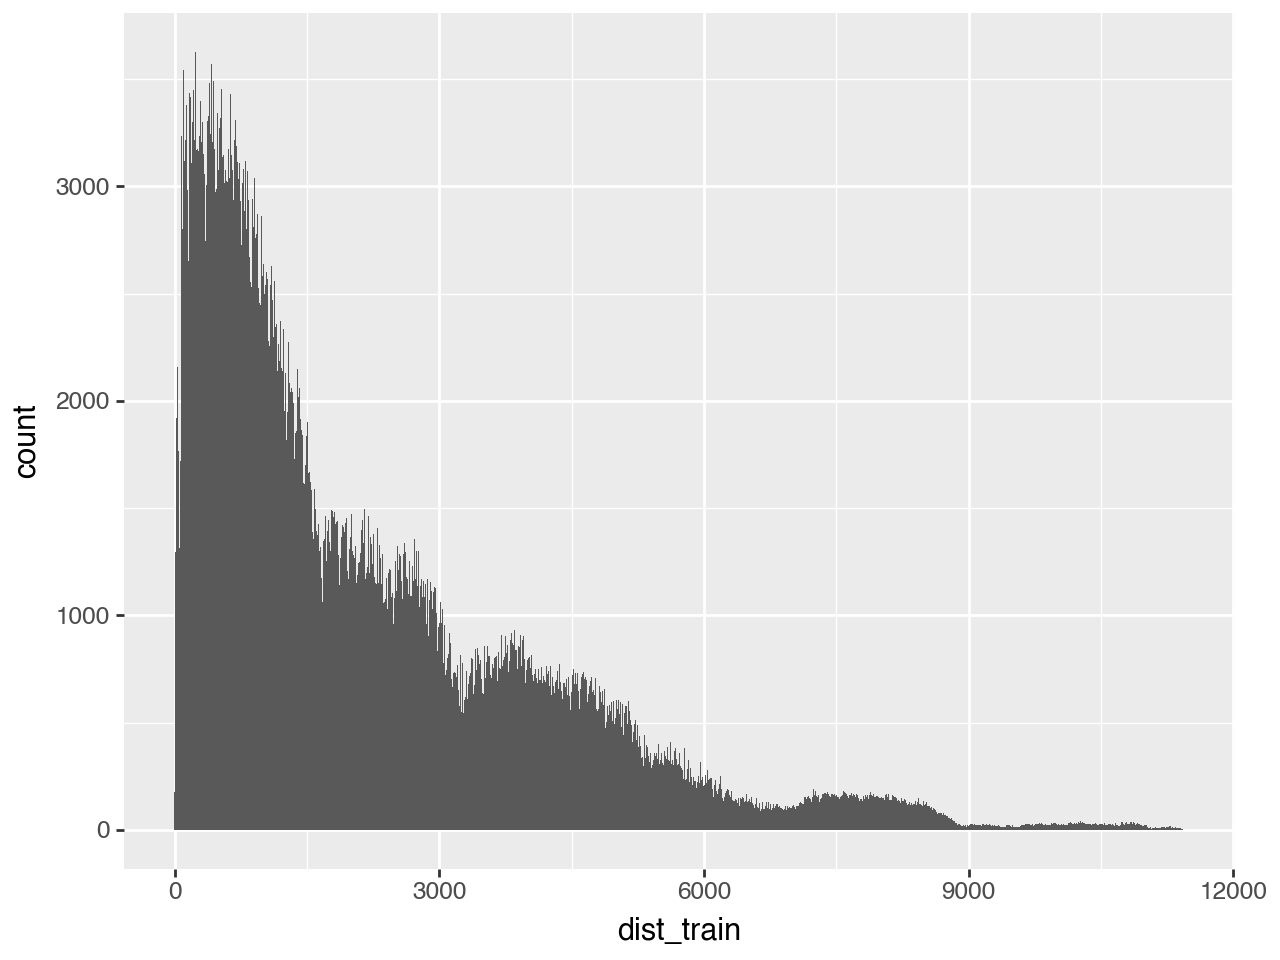

In [124]:
plot = (
    ggplot(ndf) +
    aes(x='dist_train') +
    geom_histogram(binwidth=10)
)
plot

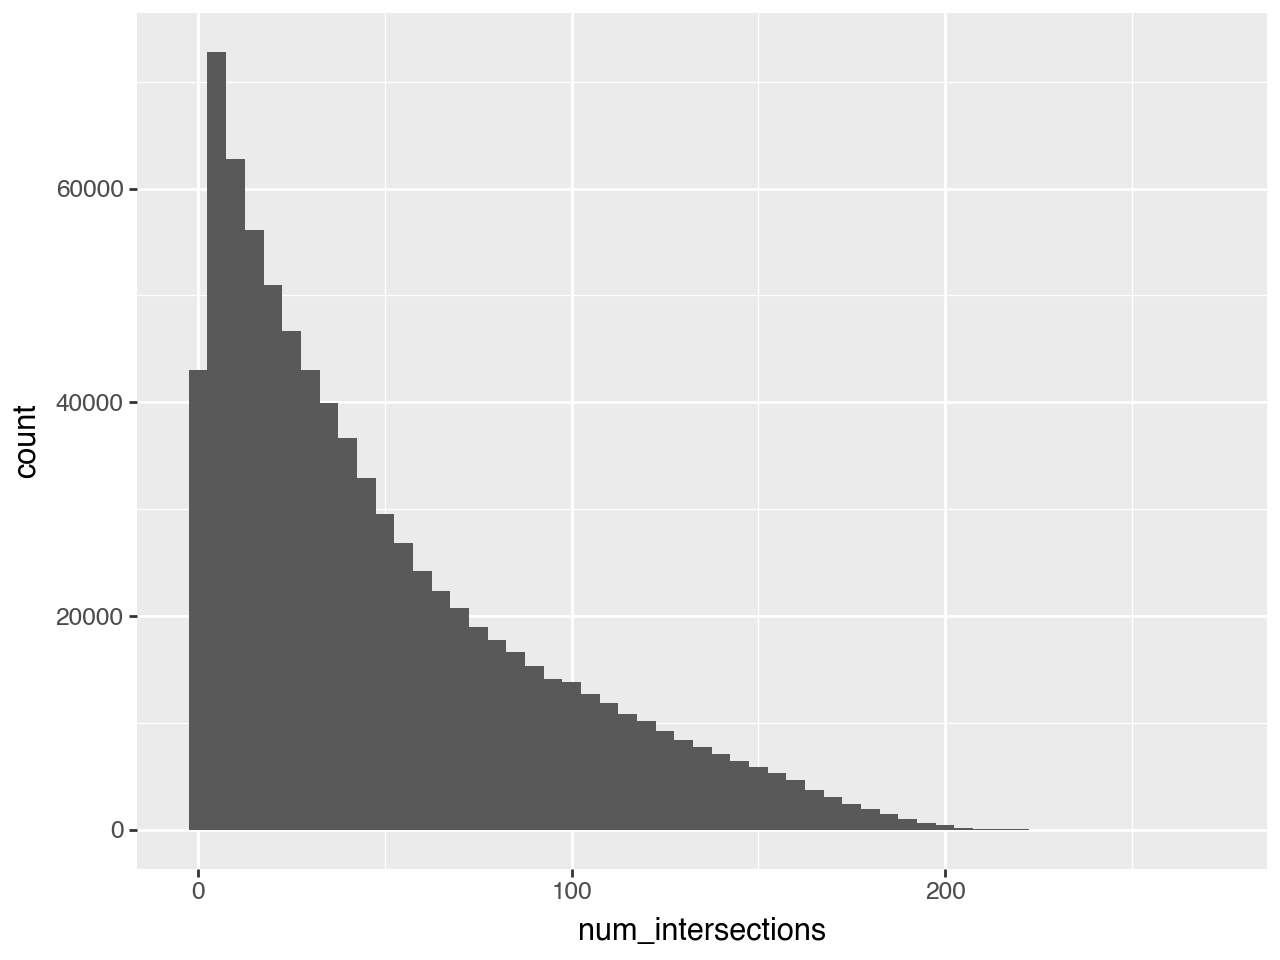

In [128]:
plot = (
    ggplot(ndf) +
    aes(x='num_intersections') +
    geom_histogram(binwidth=5)
)
plot

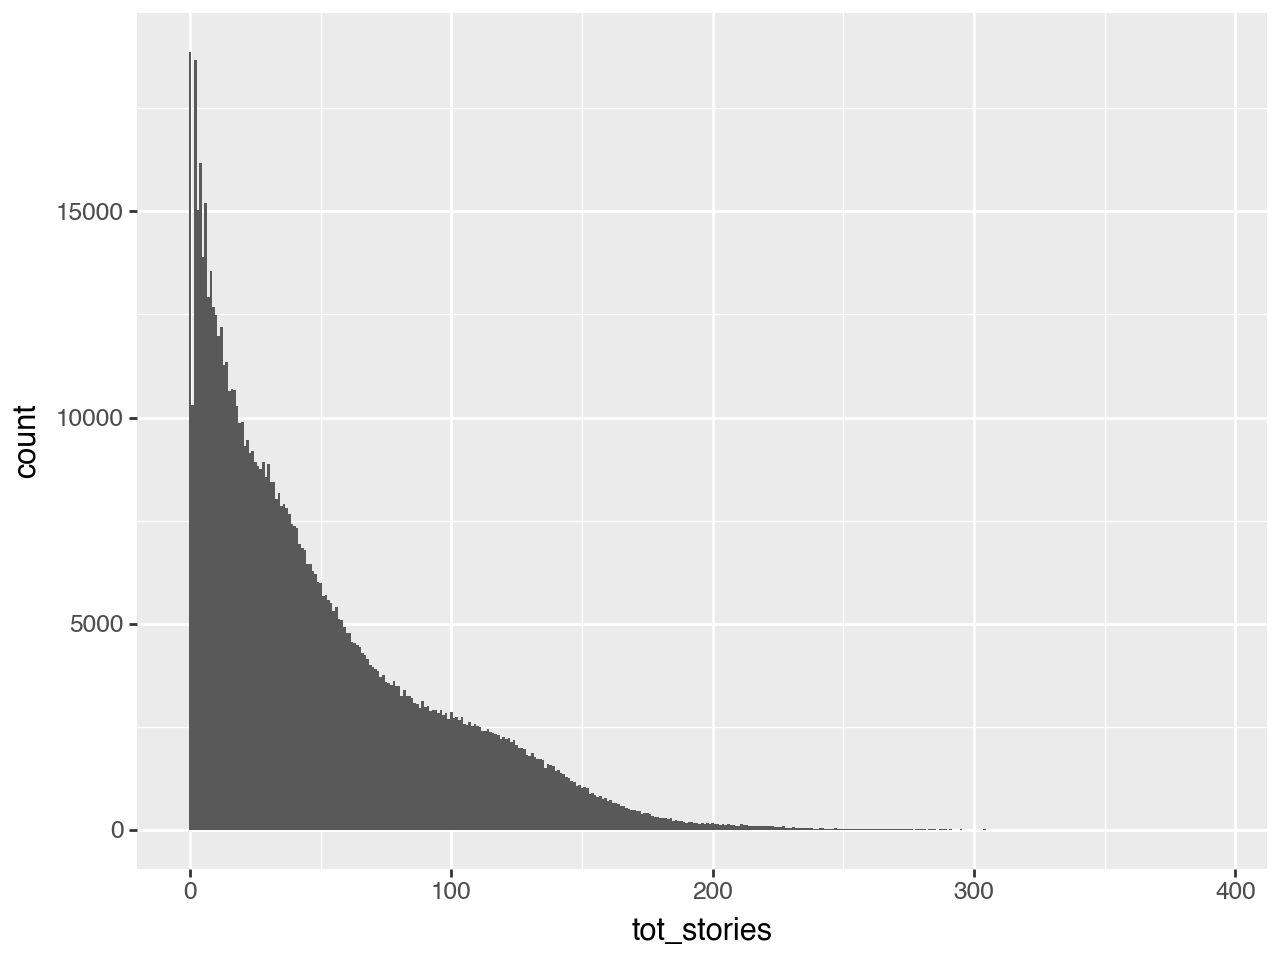

In [132]:
plot = (
    ggplot(ndf) +
    aes(x='tot_stories') +
    geom_histogram(binwidth=1)
)
plot

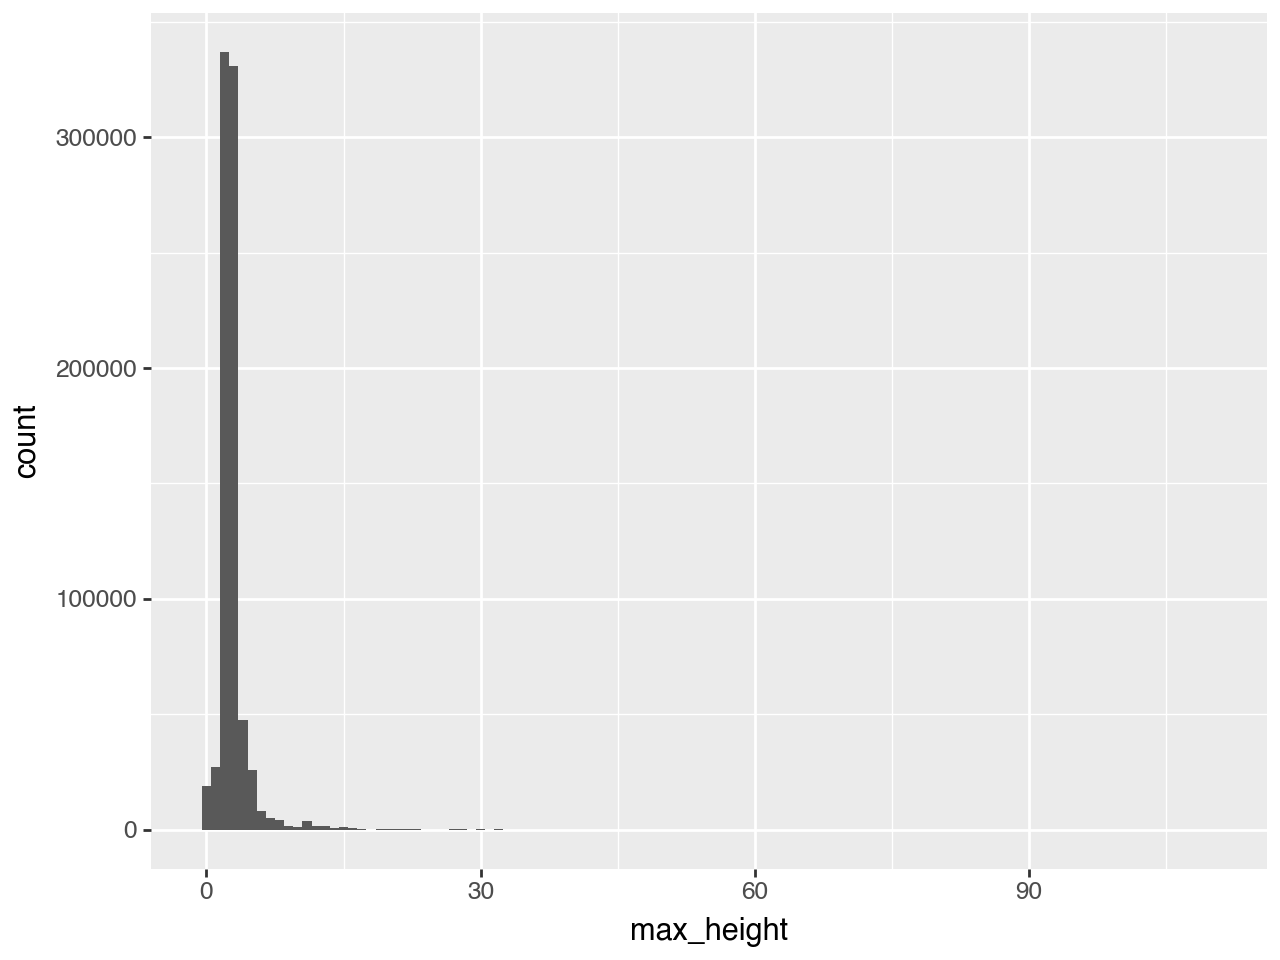

In [131]:
plot = (
    ggplot(ndf) +
    aes(x='max_height') +
    geom_histogram(binwidth=1)
)
plot

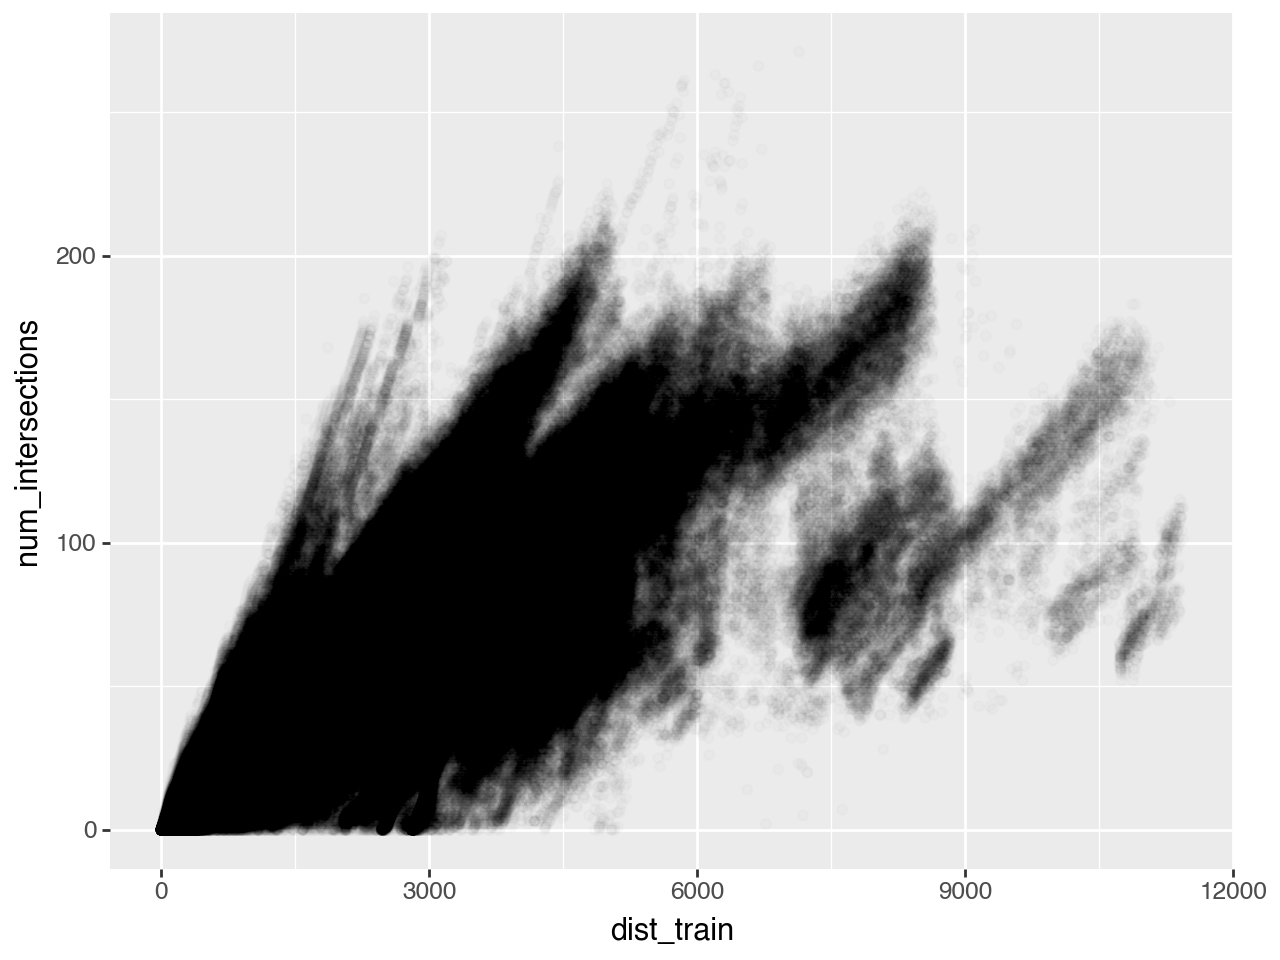

In [136]:
plot = (
    ggplot(ndf) +
    aes(x='dist_train', y='num_intersections') +
    geom_point(alpha=0.01)
)
plot